In [3]:
import pandas as pd
import warnings
import matplotlib.pyplot as plt
import seaborn as sb
import numpy as np
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, MinMaxScaler
from tensorflow.keras.models import Model
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Input
from tensorflow.keras.optimizers import Adam

%matplotlib inline
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_excel("Cleaned_Dataset/FireCADRMS_inci_types_latest.xlsx")
df.head()

,unique_Id,inci_no,inci_type,incident_category,Incident_Type_Description,Property_Loss_Value,Content_Loss_Value,Property_Value,Content_Value,Civilian_Fatal,...,prop_use,Property_Damage_Category,Property_Damage_Description,Received_Datetime,Dispatched_Datetime,Arrival_Datetime,Cleared_Datetime,DAUID,Longitude,Latitude
0,397231,20-0006971,89,I,Other Medical/Resuscitator Call ...,0,0,0,0,0,...,355,350,"Hotel, Motel, Lodging - 4 or more guests or su...",2020-10-31 05:21:00,2020-10-31 05:21:00,2020-10-31 05:27:00,2020-10-31 05:33:00,35431013.0,-79.697299,44.364071
1,397468,20-0007034,89,I,Other Medical/Resuscitator Call ...,0,0,0,0,0,...,323,320,Multi-Unit Dwelling - Over 12 Units ...,2020-11-02 17:48:00,2020-11-02 17:48:00,2020-11-02 17:53:00,2020-11-02 18:22:00,35431321.0,-79.699290,44.354853
2,397549,20-0007052,89,I,Other Medical/Resuscitator Call ...,0,0,0,0,0,...,355,350,"Hotel, Motel, Lodging - 4 or more guests or su...",2020-11-03 15:16:00,2020-11-03 15:16:00,2020-11-03 15:22:00,2020-11-03 15:39:00,35431013.0,-79.697299,44.364071
3,398004,20-0007183,89,I,Other Medical/Resuscitator Call ...,0,0,0,0,0,...,323,320,Multi-Unit Dwelling - Over 12 Units ...,2020-11-09 02:53:00,2020-11-09 02:53:00,2020-11-09 02:59:00,2020-11-09 03:06:00,35431321.0,-79.699290,44.354853
4,398196,20-0007238,89,I,Other Medical/Resuscitator Call ...,0,0,0,0,0,...,355,350,"Hotel, Motel, Lodging - 4 or more guests or su...",2020-11-11 00:38:00,2020-11-11 00:38:00,2020-11-11 00:45:00,2020-11-11 00:51:00,35431013.0,-79.697299,44.364071


In [3]:
df.shape

(40814, 21)

In [4]:
# Check for missing values in each column
missing_values = df.isnull().sum()
print(missing_values)

unique_Id                        0
inci_no                          0
inci_type                        0
incident_category                0
Incident_Type_Description        0
Property_Loss_Value              0
Content_Loss_Value               0
Property_Value                   0
Content_Value                    0
Civilian_Fatal                   0
Civilian_Injuries                0
prop_use                         0
Property_Damage_Category         0
Property_Damage_Description      0
Received_Datetime                0
Dispatched_Datetime              0
Arrival_Datetime               408
Cleared_Datetime                 4
DAUID                          245
Longitude                        0
Latitude                         0
dtype: int64


In [5]:
import geopandas as gpd
from shapely.geometry import Point
import pandas as pd
import matplotlib.pyplot as plt

da_shapefile_path = 'lda_000b21a_e'

da_gdf = gpd.read_file(da_shapefile_path)

print(f"Dissemination Area CRS: {da_gdf.crs}")
print(f"Dissemination Area Columns: {da_gdf.columns}")

# Create a GeoDataFrame with your coordinates
gdf = gpd.GeoDataFrame(
    df,
    geometry=[Point(xy) for xy in zip(df['Longitude'], df['Latitude'])],
    crs="EPSG:4326"  # Assuming your coordinates are in WGS84
)

# Check the CRS of the point data
print(f"Original Points CRS: {gdf.crs}")

# Reproject point data to match the CRS of the dissemination area shapefile if needed
if gdf.crs != da_gdf.crs:
    gdf = gdf.to_crs(da_gdf.crs)

print(f"Reprojected Points CRS: {gdf.crs}")

result = gpd.sjoin(gdf, da_gdf, how="left", op="within")

print(f"Result Columns: {result.columns}")

# Add the new DAUID to the original dataframe
df['DAUID_new'] = result['DAUID_right']

print(df.head())

Dissemination Area CRS: EPSG:3347
Dissemination Area Columns: Index(['DAUID', 'DGUID', 'LANDAREA', 'PRUID', 'geometry'], dtype='object')
Original Points CRS: EPSG:4326
Reprojected Points CRS: EPSG:3347
Result Columns: Index(['unique_Id', 'inci_no', 'inci_type', 'incident_category',
       'Incident_Type_Description', 'Property_Loss_Value',
       'Content_Loss_Value', 'Property_Value', 'Content_Value',
       'Civilian_Fatal', 'Civilian_Injuries', 'prop_use',
       'Property_Damage_Category', 'Property_Damage_Description',
       'Received_Datetime', 'Dispatched_Datetime', 'Arrival_Datetime',
       'Cleared_Datetime', 'DAUID_left', 'Longitude', 'Latitude', 'geometry',
       'index_right', 'DAUID_right', 'DGUID', 'LANDAREA', 'PRUID'],
      dtype='object')
   unique_Id     inci_no  inci_type          incident_category  \
0     397231  20-0006971         89  I                           
1     397468  20-0007034         89  I                           
2     397549  20-0007052         

In [4]:
df = pd.read_excel("Cleaned_Dataset/new_DA.xlsx")
df.head()

,unique_Id,inci_no,inci_type,incident_category,Incident_Type_Description,Property_Loss_Value,Content_Loss_Value,Property_Value,Content_Value,Civilian_Fatal,...,Property_Damage_Category,Property_Damage_Description,Received_Datetime,Dispatched_Datetime,Arrival_Datetime,Cleared_Datetime,DAUID,Longitude,Latitude,DAUID_new
0,397231,20-0006971,89,I,Other Medical/Resuscitator Call ...,0,0,0,0,0,...,350,"Hotel, Motel, Lodging - 4 or more guests or su...",2020-10-31 05:21:00,2020-10-31 05:21:00,2020-10-31 05:27:00,2020-10-31 05:33:00,35431013.0,-79.697299,44.364071,35431014
1,397468,20-0007034,89,I,Other Medical/Resuscitator Call ...,0,0,0,0,0,...,320,Multi-Unit Dwelling - Over 12 Units ...,2020-11-02 17:48:00,2020-11-02 17:48:00,2020-11-02 17:53:00,2020-11-02 18:22:00,35431321.0,-79.699290,44.354853,35430680
2,397549,20-0007052,89,I,Other Medical/Resuscitator Call ...,0,0,0,0,0,...,350,"Hotel, Motel, Lodging - 4 or more guests or su...",2020-11-03 15:16:00,2020-11-03 15:16:00,2020-11-03 15:22:00,2020-11-03 15:39:00,35431013.0,-79.697299,44.364071,35431014
3,398004,20-0007183,89,I,Other Medical/Resuscitator Call ...,0,0,0,0,0,...,320,Multi-Unit Dwelling - Over 12 Units ...,2020-11-09 02:53:00,2020-11-09 02:53:00,2020-11-09 02:59:00,2020-11-09 03:06:00,35431321.0,-79.699290,44.354853,35430680
4,398196,20-0007238,89,I,Other Medical/Resuscitator Call ...,0,0,0,0,0,...,350,"Hotel, Motel, Lodging - 4 or more guests or su...",2020-11-11 00:38:00,2020-11-11 00:38:00,2020-11-11 00:45:00,2020-11-11 00:51:00,35431013.0,-79.697299,44.364071,35431014


In [5]:
# Display DAUID and DAUID_new columns
print(df[['DAUID', 'DAUID_new']])

# Compare the two columns
same_values = df[df['DAUID'] == df['DAUID_new']].shape[0]
different_values = df[df['DAUID'] != df['DAUID_new']].shape[0]
nan_dauid = df['DAUID'].isna().sum()
nan_dauid_new = df['DAUID_new'].isna().sum()

print(f"Same values: {same_values}")
print(f"Different values: {different_values}")
print(f"NaN values in DAUID: {nan_dauid}")
print(f"NaN values in DAUID_new: {nan_dauid_new}")

file_path = 'new_DA.xlsx'

# Save the DataFrame to an Excel file
df.to_excel(file_path, index=False)

print(f"DataFrame saved to {file_path}")

            DAUID  DAUID_new
0      35431013.0   35431014
1      35431321.0   35430680
2      35431013.0   35431014
3      35431321.0   35430680
4      35431013.0   35431014
...           ...        ...
40809         NaN   35430639
40810         NaN   35431364
40811         NaN   35431367
40812         NaN   35431367
40813         NaN   35431367

[40814 rows x 2 columns]
Same values: 24250
Different values: 16564
NaN values in DAUID: 245
NaN values in DAUID_new: 0
DataFrame saved to new_DA.xlsx


In [6]:
import numpy as np

# Convert Received_Datetime to datetime and sort
df['Received_Datetime'] = pd.to_datetime(df['Received_Datetime'])
df['Dispatched_Datetime'] = pd.to_datetime(df['Dispatched_Datetime'])
df['Arrival_Datetime'] = pd.to_datetime(df['Arrival_Datetime'])
df.sort_values('Received_Datetime', inplace=True)

# Encode categorical features
label_encoders = {}
for column in ['incident_category', 'DAUID_new']:
    le = LabelEncoder()
    df[column] = le.fit_transform(df[column])
    label_encoders[column] = le
    num_unique_categories = len(le.classes_)
    print(f"Number of unique categories in '{column}': {num_unique_categories}")

# Define sequence length (n_steps) and output sequence length (n_output_steps)
n_steps = 16  # Number of previous steps to consider for prediction
n_output_steps = 5  # Number of steps ahead to predict

# Initialize lists to store sequences
sequences_x = []
sequences_y = []

# Iterate over the dataset to create sequences
for i in range(len(df) - n_steps - n_output_steps):
    # Define input sequence (x)
    x_seq = df.iloc[i:i+n_steps][['DAUID_new', 'Received_Datetime', 'incident_category', 'Longitude', 'Latitude', 'Dispatched_Datetime', 'Arrival_Datetime']].values
    sequences_x.append(x_seq)
    
    # Define output sequence (y)
    y_seq = df.iloc[i+n_steps:i+n_steps+n_output_steps][['DAUID_new', 'Received_Datetime', 'incident_category']].values
    sequences_y.append(y_seq)

# Convert lists to numpy arrays
x = np.array(sequences_x)
y = np.array(sequences_y)

# Check the shape of x and y arrays
print("Shape of x:", x.shape)  # (num_samples, n_steps, num_features)
print("Shape of y:", y.shape)  # (num_samples, n_output_steps, num_output_features)

Number of unique categories in 'incident_category': 10
Number of unique categories in 'DAUID_new': 246
Shape of x: (40793, 16, 7)
Shape of y: (40793, 5, 3)


In [7]:
from sklearn.model_selection import train_test_split

# Split the data into train and test sets
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, shuffle=False)

# Further split train into train and validation sets
x_train, x_val, y_train, y_val = train_test_split(x_train, y_train, test_size=0.2, shuffle=False)

x_test_df = pd.DataFrame(x_test.reshape(x_test.shape[0], -1))
y_test_df = pd.DataFrame(y_test.reshape(y_test.shape[0], -1))

x_test_file = 'x_test.xlsx'
y_test_file = 'y_test.xlsx'

# Save DataFrames to Excel
x_test_df.to_excel(x_test_file, index=False, header=False)
y_test_df.to_excel(y_test_file, index=False, header=False)

# Verify the shapes of the datasets
print("Train shapes:")
print("x_train:", x_train.shape)
print("y_train:", y_train.shape)
print("Validation shapes:")
print("x_val:", x_val.shape)
print("y_val:", y_val.shape)
print("Test shapes:")
print("x_test:", x_test.shape)
print("y_test:", y_test.shape)

Train shapes:
x_train: (26107, 16, 7)
y_train: (26107, 5, 3)
Validation shapes:
x_val: (6527, 16, 7)
y_val: (6527, 5, 3)
Test shapes:
x_test: (8159, 16, 7)
y_test: (8159, 5, 3)


In [8]:
from keras.models import Model
from keras.layers import LSTM, Dense, Input

num_classes_da = 246  
num_classes_type = 10

In [9]:
print("Data type of x_train:", x_train.dtype)
print("Data type of y_train:", y_train.dtype)
print("Data type of x_val:", x_val.dtype)
print("Data type of y_val:", y_val.dtype)

Data type of x_train: object
Data type of y_train: object
Data type of x_val: object
Data type of y_val: object


In [10]:
print(y_train.shape)  # Print the shape of the array
print(y_train[0])     # Access the first row of the array

(26107, 5, 3)
[[138 Timestamp('2020-01-01 13:40:00') 8]
 [136 Timestamp('2020-01-01 14:04:00') 4]
 [59 Timestamp('2020-01-01 14:26:00') 8]
 [80 Timestamp('2020-01-01 14:40:00') 8]
 [80 Timestamp('2020-01-01 19:51:00') 7]]


In [11]:
# Convert Received_Datetime to Unix timestamp (seconds since Epoch)
y_train_timestamps_unix = np.zeros_like(y_train[:, :, 1], dtype=np.int64)
for i in range(len(y_train)):
    for j in range(len(y_train[0])):
        y_train_timestamps_unix[i, j] = int(y_train[i, j, 1].timestamp())  # Convert Timestamp to Unix timestamp

# Reshape to match LSTM input requirements
y_train_timestamps_unix = y_train_timestamps_unix.reshape(-1, 5, 1)

In [12]:
# # Reshape to match LSTM input requirements
# y_train_timestamps_unix = y_train_timestamps_unix.reshape(-1, 5, 1)

# Concatenate relevant columns back together
y_train_final = np.concatenate([y_train[:, :, [0]], y_train_timestamps_unix, y_train[:, :, [2]]], axis=2)

# Print the shapes and first few elements to verify
print("Shape of y_train_final:", y_train_final.shape)
print("\nFirst few elements of y_train_final:")
print(y_train_final[:2])

Shape of y_train_final: (26107, 5, 3)

First few elements of y_train_final:
[[[138 1577886000 8]
  [136 1577887440 4]
  [59 1577888760 8]
  [80 1577889600 8]
  [80 1577908260 7]]

 [[136 1577887440 4]
  [59 1577888760 8]
  [80 1577889600 8]
  [80 1577908260 7]
  [225 1577910060 8]]]


In [13]:
# Convert Received_Datetime to Unix timestamp (seconds since Epoch)
y_val_timestamps_unix = np.zeros_like(y_val[:, :, 1], dtype=np.int64)
for i in range(len(y_val)):
    for j in range(len(y_val[0])):
        y_val_timestamps_unix[i, j] = int(y_val[i, j, 1].timestamp())  # Convert Timestamp to Unix timestamp

# Reshape to match LSTM input requirements
y_val_timestamps_unix = y_val_timestamps_unix.reshape(-1, 5, 1)

In [14]:
# Concatenate relevant columns back together
y_val_final = np.concatenate([y_val[:, :, [0]], y_val_timestamps_unix, y_val[:, :, [2]]], axis=2)

# Print the shapes and first few elements to verify
print("Shape of y_val_final:", y_val_final.shape)
print("\nFirst few elements of y_val_final:")
print(y_val_final[:2])

Shape of y_val_final: (6527, 5, 3)

First few elements of y_val_final:
[[[218 1663960800 4]
  [206 1663962240 8]
  [95 1663964820 8]
  [49 1663965960 4]
  [198 1663966440 5]]

 [[206 1663962240 8]
  [95 1663964820 8]
  [49 1663965960 4]
  [198 1663966440 5]
  [128 1663971540 8]]]


In [15]:
# Check data types and shapes of x_train and y_train_final
print("x_train shape:", x_train.shape)
print("y_train_final shape:", y_train_final.shape)
print("x_train dtype:", x_train.dtype)
print("y_train_final dtype:", y_train_final.dtype)


x_train shape: (26107, 16, 7)
y_train_final shape: (26107, 5, 3)
x_train dtype: object
y_train_final dtype: object


In [16]:
import numpy as np
import pandas as pd
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, TimeDistributed, RepeatVector
from tensorflow.keras.optimizers import Adam

# Initialize arrays to store Unix timestamps
x_train_received_unix = np.zeros_like(x_train[:, :, 1], dtype=np.int64)
x_train_dispatched_unix = np.zeros_like(x_train[:, :, 5], dtype=np.int64)
x_train_arrival_unix = np.zeros_like(x_train[:, :, 6], dtype=np.int64)

# Convert datetime columns to Unix timestamps for x_train
for i in range(len(x_train)):
    for j in range(len(x_train[0])):
        if pd.isna(x_train[i, j, 1]):
            x_train[i, j, 1] = pd.Timestamp('1970-01-01 00:00:00')
        if pd.isna(x_train[i, j, 5]):
            x_train[i, j, 5] = pd.Timestamp('1970-01-01 00:00:00')
        if pd.isna(x_train[i, j, 6]):
            x_train[i, j, 6] = pd.Timestamp('1970-01-01 00:00:00')
        x_train_received_unix[i, j] = int(pd.Timestamp(x_train[i, j, 1]).timestamp())
        x_train_dispatched_unix[i, j] = int(pd.Timestamp(x_train[i, j, 5]).timestamp())
        x_train_arrival_unix[i, j] = int(pd.Timestamp(x_train[i, j, 6]).timestamp())

# Reshape to match LSTM input requirements
x_train_received_unix = x_train_received_unix.reshape(-1, 16, 1)
x_train_dispatched_unix = x_train_dispatched_unix.reshape(-1, 16, 1)
x_train_arrival_unix = x_train_arrival_unix.reshape(-1, 16, 1)

# Concatenate relevant columns back together
x_train_final = np.concatenate([
    x_train[:, :, [0, 2, 3, 4]], 
    x_train_received_unix, 
    x_train_dispatched_unix, 
    x_train_arrival_unix
], axis=2)

# Repeat for validation data (x_val)
x_val_received_unix = np.zeros_like(x_val[:, :, 1], dtype=np.int64)
x_val_dispatched_unix = np.zeros_like(x_val[:, :, 5], dtype=np.int64)
x_val_arrival_unix = np.zeros_like(x_val[:, :, 6], dtype=np.int64)

for i in range(len(x_val)):
    for j in range(len(x_val[0])):
        if pd.isna(x_val[i, j, 1]):
            x_val[i, j, 1] = pd.Timestamp('1970-01-01 00:00:00')
        if pd.isna(x_val[i, j, 5]):
            x_val[i, j, 5] = pd.Timestamp('1970-01-01 00:00:00')
        if pd.isna(x_val[i, j, 6]):
            x_val[i, j, 6] = pd.Timestamp('1970-01-01 00:00:00')
        x_val_received_unix[i, j] = int(pd.Timestamp(x_val[i, j, 1]).timestamp())
        x_val_dispatched_unix[i, j] = int(pd.Timestamp(x_val[i, j, 5]).timestamp())
        x_val_arrival_unix[i, j] = int(pd.Timestamp(x_val[i, j, 6]).timestamp())

# Reshape to match LSTM input requirements
x_val_received_unix = x_val_received_unix.reshape(-1, 16, 1)
x_val_dispatched_unix = x_val_dispatched_unix.reshape(-1, 16, 1)
x_val_arrival_unix = x_val_arrival_unix.reshape(-1, 16, 1)

# Concatenate relevant columns back together
x_val_final = np.concatenate([
    x_val[:, :, [0, 2, 3, 4]], 
    x_val_received_unix, 
    x_val_dispatched_unix, 
    x_val_arrival_unix
], axis=2)

# Convert to float32
x_train_final = x_train_final.astype('float32')
x_val_final = x_val_final.astype('float32')
y_train_final = y_train_final.astype('float32')
y_val_final = y_val_final.astype('float32')

In [17]:
from keras.models import Model
from keras.layers import Input, LSTM, TimeDistributed, Dense

input_shape = (16, 7)  # Input shape with sequence length 16 and 7 features
num_classes_da = len(label_encoders['DAUID_new'].classes_)
num_classes_type = len(label_encoders['incident_category'].classes_)

# Define the model architecture
inputs = Input(shape=input_shape)
lstm_output = LSTM(64, return_sequences=True)(inputs)
output_da = TimeDistributed(Dense(num_classes_da, activation='softmax'), name='output_da')(lstm_output[:, -5:, :])
output_type = TimeDistributed(Dense(num_classes_type, activation='softmax'), name='output_type')(lstm_output[:, -5:, :])

# Create the model
model = Model(inputs=inputs, outputs=[output_da, output_type])

# Compile the model with appropriate loss functions
model.compile(optimizer='adam',
              loss={'output_da': 'sparse_categorical_crossentropy', 'output_type': 'sparse_categorical_crossentropy'},
              metrics={'output_da': 'accuracy', 'output_type': 'accuracy'})

# Print model summary to verify output shapes
model.summary()
print(f"x_train_final shape: {x_train_final.shape}")
print(f"y_train_final shape: {y_train_final.shape}")
print(f"x_val_final shape: {x_val_final.shape}")
print(f"y_val_final shape: {y_val_final.shape}")


# Training and evaluation
history = model.fit(x_train_final,
                    {'output_da': y_train_final[:, :, 0], 'output_type': y_train_final[:, :, 2]},
                    epochs=50,
                    batch_size=32,
                    validation_data=(x_val_final,
                                     {'output_da': y_val_final[:, :, 0], 'output_type': y_val_final[:, :, 2]}))

# Evaluation
loss, accuracy_da, accuracy_type = model.evaluate(x_val_final,
                                                  {'output_da': y_val_final[:, :, 0], 'output_type': y_val_final[:, :, 2]})
print(f"Validation Accuracy - DA: {accuracy_da}, Type: {accuracy_type}")


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 16, 7)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm (LSTM)         │ (None, 16, 64)    │     18,432 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item (GetItem)  │ (None, 5, 64)     │          0 │ lstm[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_1          │ (None, 5, 64)     │          0 │ lstm[0][0]        │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output_da           │ (None, 5, 246)    │     15,990 │ get_item[0][0]    │
│ (TimeDistributed)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output_type         │ (None, 5, 10)     │        650 │ get_item_1[0][0]  │
│ (TimeDistributed)   │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 35,072 (137.00 KB)

 Trainable params: 35,072 (137.00 KB)

 Non-trainable params: 0 (0.00 B)

x_train_final shape: (26107, 16, 7)
y_train_final shape: (26107, 5, 3)
x_val_final shape: (6527, 16, 7)
y_val_final shape: (6527, 5, 3)
Epoch 1/50
816/816 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - loss: 6.5619 - output_da_accuracy: 0.0224 - output_type_accuracy: 0.6241 - val_loss: 6.1917 - val_output_da_accuracy: 0.0291 - val_output_type_accuracy: 0.7203
Epoch 2/50
816/816 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - loss: 6.2898 - output_da_accuracy: 0.0272 - output_type_accuracy: 0.6896 - val_loss: 6.1909 - val_output_da_accuracy: 0.0291 - val_output_type_accuracy: 0.7203
Epoch 3/50
816/816 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - loss: 6.2881 - output_da_accuracy: 0.0276 - output_type_accuracy: 0.6904 - val_loss: 6.1879 - val_output_da_accuracy: 0.0268 - val_output_type_accuracy: 0.7203
Epoch 4/50
816/816 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - loss: 6.3008 - output_da_accuracy: 0.0263 - output_type_accuracy: 0.6890 - val_loss: 6.1923 - val_output_da_accuracy: 0.0264 - val_output_type_accuracy: 0.7203
Epoch 5/

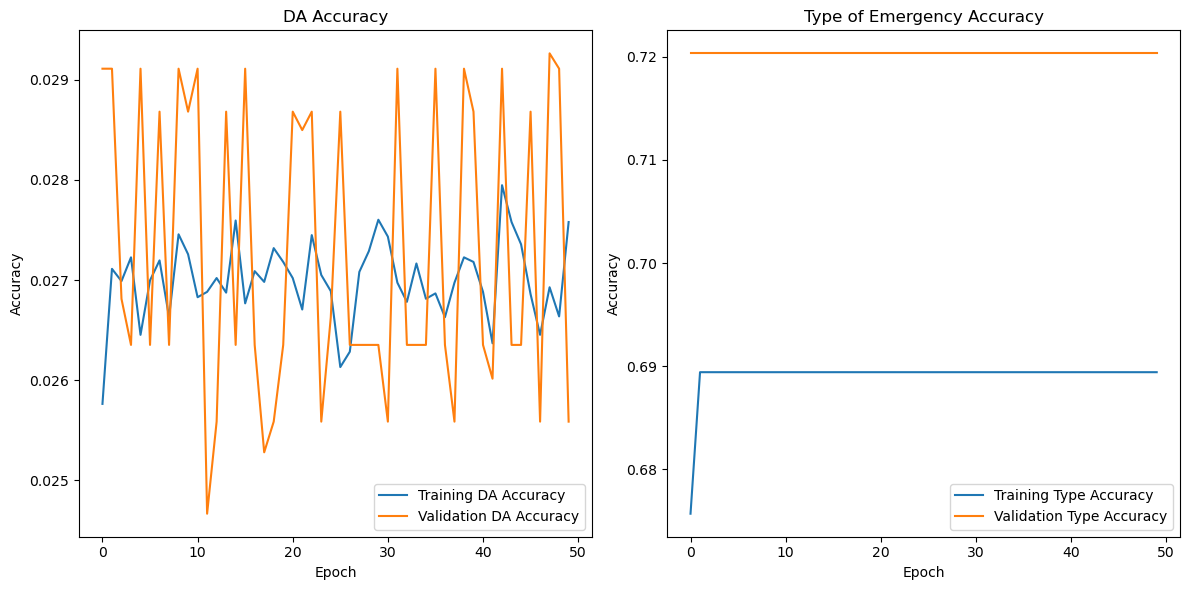

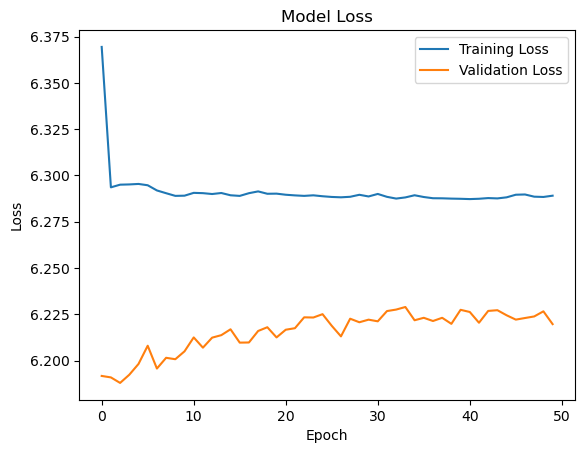

In [18]:
# Extract accuracy and loss values
acc_da = history.history['output_da_accuracy']
val_acc_da = history.history['val_output_da_accuracy']
acc_type = history.history['output_type_accuracy']
val_acc_type = history.history['val_output_type_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

# Plot accuracy for DA
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.plot(acc_da, label='Training DA Accuracy')
plt.plot(val_acc_da, label='Validation DA Accuracy')
plt.title('DA Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Plot accuracy for Type of Emergency
plt.subplot(1, 2, 2)
plt.plot(acc_type, label='Training Type Accuracy')
plt.plot(val_acc_type, label='Validation Type Accuracy')
plt.title('Type of Emergency Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

# Plot loss
plt.figure()
plt.plot(loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [28]:
model.summary()
import joblib

# Save the model
joblib.dump(model, 'Backend-app/Trained_models/lstm_trained_model1.pkl')

# Load the model
loaded_model = joblib.load('Backend-app/Trained_models/lstm_trained_model1.pkl')

# model.save('Backend-app/Trained_models/lstm_trained_model.h5') 

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 16, 7)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm (LSTM)         │ (None, 16, 64)    │     18,432 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item (GetItem)  │ (None, 5, 64)     │          0 │ lstm[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_1          │ (None, 5, 64)     │          0 │ lstm[0][0]        │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output_da           │ (None, 5, 246)    │     15,990 │ get_item[0][0]    │
│ (TimeDistributed)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output_type         │ (None, 5, 10)     │        650 │ get_item_1[0][0]  │
│ (TimeDistributed)   │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 105,218 (411.01 KB)

 Trainable params: 35,072 (137.00 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 70,146 (274.01 KB)

In [32]:
import pandas as pd
from sklearn.metrics import mean_squared_error

# Load from Excel
x_test_df = pd.read_excel('x_test.xlsx', header=None)
y_test_df = pd.read_excel('y_test.xlsx', header=None)

# Convert back to NumPy arrays and reshape
x_test = np.array(x_test_df).reshape(-1, 16, 7)
y_test = np.array(y_test_df).reshape(-1, 5, 3)

# Verify shapes
print("Shape of x_test:", x_test.shape)
print("Shape of y_test:", y_test.shape)

Shape of x_test: (8159, 16, 7)
Shape of y_test: (8159, 5, 3)


In [33]:
# Repeat for test data (x_test)
x_test_received_unix = np.zeros_like(x_test[:, :, 1], dtype=np.int64)
x_test_dispatched_unix = np.zeros_like(x_test[:, :, 5], dtype=np.int64)
x_test_arrival_unix = np.zeros_like(x_test[:, :, 6], dtype=np.int64)

for i in range(len(x_test)):
    for j in range(len(x_test[0])):
        if pd.isna(x_test[i, j, 1]):
            x_test[i, j, 1] = pd.Timestamp('1970-01-01 00:00:00')
        if pd.isna(x_test[i, j, 5]):
            x_val[i, j, 5] = pd.Timestamp('1970-01-01 00:00:00')
        if pd.isna(x_test[i, j, 6]):
            x_test[i, j, 6] = pd.Timestamp('1970-01-01 00:00:00')
        x_test_received_unix[i, j] = int(pd.Timestamp(x_test[i, j, 1]).timestamp())
        x_test_dispatched_unix[i, j] = int(pd.Timestamp( x_test[i, j, 5]).timestamp())
        x_test_arrival_unix[i, j] = int(pd.Timestamp(x_test[i, j, 6]).timestamp())

# Reshape to match LSTM input requirements
x_test_received_unix = x_test_received_unix.reshape(-1, 16, 1)
x_test_dispatched_unix = x_test_dispatched_unix.reshape(-1, 16, 1)
x_test_arrival_unix = x_test_arrival_unix.reshape(-1, 16, 1)

# Concatenate relevant columns back together
x_test_final = np.concatenate([
    x_test[:, :, [0, 2, 3, 4]], 
    x_test_received_unix, 
    x_test_dispatched_unix, 
    x_test_arrival_unix
], axis=2)


In [34]:
y_test_timestamps_unix = np.zeros_like(y_test[:, :, 1], dtype=np.int64)
for i in range(len(y_test)):
    for j in range(len(y_test[0])):
        y_test_timestamps_unix[i, j] = int(y_test[i, j, 1].timestamp())  # Convert Timestamp to Unix timestamp

# Reshape to match LSTM input requirements
y_test_timestamps_unix = y_test_timestamps_unix.reshape(-1, 5, 1)

# Print the converted timestamps for validation
print("Converted y_test timestamps (Unix):")
print(y_test_timestamps_unix)

Converted y_test timestamps (Unix):
[[[1682333880]
  [1682336760]
  [1682338560]
  [1682338620]
  [1682339820]]

 [[1682336760]
  [1682338560]
  [1682338620]
  [1682339820]
  [1682347320]]

 [[1682338560]
  [1682338620]
  [1682339820]
  [1682347320]
  [1682351640]]

 ...

 [[1704040620]
  [1704043740]
  [1704045060]
  [1704045300]
  [1704046860]]

 [[1704043740]
  [1704045060]
  [1704045300]
  [1704046860]
  [1704052860]]

 [[1704045060]
  [1704045300]
  [1704046860]
  [1704052860]
  [1704058080]]]


In [35]:
# Concatenate relevant columns back together
y_test_final = np.concatenate([y_test[:, :, [0]], y_test_timestamps_unix, y_test[:, :, [2]]], axis=2)

# Print the shapes and first few elements to verify
print("Shape of y_test_final:", y_test_final.shape)
print("\nFirst few elements of y_test_final:")
print(y_test_final[:2])

Shape of y_test_final: (8159, 5, 3)

First few elements of y_test_final:
[[[127 1682333880 8]
  [123 1682336760 8]
  [232 1682338560 4]
  [91 1682338620 8]
  [226 1682339820 2]]

 [[123 1682336760 8]
  [232 1682338560 4]
  [91 1682338620 8]
  [226 1682339820 2]
  [184 1682347320 4]]]


In [36]:
x_test_final = x_test_final.astype('float32')
y_test_final = y_test_final.astype('float32')

In [37]:
# Verify the shapes and types before prediction
print("Shape of x_test_final:", x_test_final.shape)
print("Shape of y_test_final:", y_test_final.shape)
print("x_test_final dtype:", x_test_final.dtype)
print("y_test_final dtype:", y_test_final.dtype)

Shape of x_test_final: (8159, 16, 7)
Shape of y_test_final: (8159, 5, 3)
x_test_final dtype: float32
y_test_final dtype: float32


In [38]:
# Predict on the test data
y_pred = loaded_model.predict(x_test_final)
# print(y_pred)

# Extract the predicted DA and Type
pred_da = np.argmax(y_pred[0], axis=-1)
pred_type = np.argmax(y_pred[1], axis=-1)

# Extract the true DA and Type from y_test
true_da = y_test_final[:, :, 0]
true_type = y_test_final[:, :, 2]

# Evaluate the accuracy for DA and Type
accuracy_da = np.mean(pred_da == true_da)
accuracy_type = np.mean(pred_type == true_type)

print(f"Test Accuracy - DA: {accuracy_da}")
print(f"Test Accuracy - Type: {accuracy_type}")

255/255 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
Test Accuracy - DA: 0.028263267557298688
Test Accuracy - Type: 0.6959186174776321


In [41]:
# Predict on the test data
y_pred = loaded_model.predict(x_test_final)

# Extract the predicted DA and Type
pred_da = np.argmax(y_pred[0], axis=-1)
pred_type = np.argmax(y_pred[1], axis=-1)

# Extract the true DA and Type from y_test
true_da = y_test[:, :, 0].astype(int)
true_type = y_test[:, :, 2].astype(int)

# Inverse transform predicted and true labels
pred_da_original = label_encoders['DAUID_new'].inverse_transform(pred_da.flatten().astype(int))
pred_type_original = label_encoders['incident_category'].inverse_transform(pred_type.flatten().astype(int))
true_da_original = label_encoders['DAUID_new'].inverse_transform(true_da.flatten())
true_type_original = label_encoders['incident_category'].inverse_transform(true_type.flatten())

# Reshape to match original shape
pred_da_original = pred_da_original.reshape(pred_da.shape)
pred_type_original = pred_type_original.reshape(pred_type.shape)
true_da_original = true_da_original.reshape(true_da.shape)
true_type_original = true_type_original.reshape(true_type.shape)

print("Predicted DA (original values):")
print(pred_da_original)

print("Predicted Type (original values):")
print(pred_type_original)

print("True DA (original values):")
print(true_da_original)

print("True Type (original values):")
print(true_type_original)


255/255 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
Predicted DA (original values):
[[35431324 35431324 35431324 35431324 35431324]
 [35431324 35431324 35431324 35431324 35431324]
 [35431324 35431324 35431324 35431324 35431324]
 ...
 [35431019 35431019 35431019 35431019 35431019]
 [35431019 35431019 35431019 35431019 35431019]
 [35431019 35431019 35431019 35431019 35431019]]
Predicted Type (original values):
[['I                        ' 'I                        '
  'I                        ' 'I                        '
  'I                        ']
 ['I                        ' 'I                        '
  'I                        ' 'I                        '
  'I                        ']
 ['I                        ' 'I                        '
  'I                        ' 'I                        '
  'I                        ']
 ...
 ['I                        ' 'I                        '
  'I                        ' 'I                        '
  'I                        ']
 ['I  

In [40]:
import pickle
# Save label encoders to a file
with open('label_encoders.pkl', 'wb') as file:
    pickle.dump(label_encoders, file)

In [21]:
import tensorflow
print(tensorflow.__version__)


2.16.2


In [1]:
import keras
print(keras.__version__)

3.4.1


In [30]:
import sys
print(sys.version)

3.11.5 (main, Sep 11 2023, 08:31:25) [Clang 14.0.6 ]
